# A/B Testing

During the project, 9 hypotheses to increase the online store’s revenue were prioritized using ICE and RICE frameworks.

A/B Test Analysis:

Cumulative Analysis: Tracked revenue and average order value over time to identify which group performed better.

Outlier Removal: Extreme orders or users with unusually high activity were identified via scatter plots and percentiles (95th, 99th) and excluded to ensure results reflect the overall user base.

Statistical Testing (Z-test): Checked whether differences in conversion rates between groups were statistically significant on both raw and cleaned data.

In [1]:
# Importing libraries for analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded=files.upload()

#Importing the datasets
hypotheses=pd.read_csv('hypotheses_us.csv',sep=';')
orders=pd.read_csv('orders_us.csv',sep=',')
visits=pd.read_csv('visits_us.csv',sep=',')

Saving hypotheses_us.csv to hypotheses_us (7).csv
Saving orders_us.csv to orders_us (7).csv
Saving visits_us.csv to visits_us (7).csv


In [3]:
hypotheses.head()
#first 5 rows

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


In [4]:
orders.head()
#first 5 rows

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


In [5]:
visits.head()
#first 5 rows

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [6]:
print(f"The shape of hypotheses table: {hypotheses.shape}")
print(f"The shape of orders table: {orders.shape}")
print(f"The shape of visits table: {visits.shape}")
#shape of datasets (rows,columns)

The shape of hypotheses table: (9, 5)
The shape of orders table: (1197, 5)
The shape of visits table: (62, 3)


Among all tables, the orders table has the highest number of observations, comprising 1197 rows and 5 variables. The visits table follows with 62 rows and 5 variables, whereas the hypotheses table contains 9 rows and 5 variables.

In [7]:
print("Hypotheses info:\n")
hypotheses.info()
print("\n######################################################\n")
print("Orders info:\n")
orders.info()
print("\n######################################################\n")
print("Visits info:\n")
visits.info()
#the columns and their data types in each datasets

Hypotheses info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes

######################################################

Orders info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB

The data types of "date" in orders table and the other "date" in visits  table are object, let's convert them to date type.

In [8]:
orders['date'] = pd.to_datetime(orders['date'])
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB


Now all data types are correct.

In [9]:
visits['date'] = pd.to_datetime(visits['date'])
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


Now all data types are correct.

In [10]:
hypotheses.isnull().sum()
#Do we have null values or not in orders dataset

,0
Hypothesis,0
Reach,0
Impact,0
Confidence,0
Effort,0


We don't have any null value, so we don't need to drop or fill any column.

In [11]:
orders.isnull().sum()
#Do we have null values or not in orders dataset

,0
transactionId,0
visitorId,0
date,0
revenue,0
group,0


We don't have any null value, so we don't need to drop or fill any column.

In [12]:
visits.isnull().sum()
#Do we have null values or not in orders dataset

,0
date,0
group,0
visits,0


We don't have any null value, so we don't need to drop or fill any column.

## Comparison of Hypothesis Prioritization Using ICE and RICE

### ICE Framework

In [13]:
#ICE=(Impact * Confidence) / Effort
hypotheses['ICE']=((hypotheses['Impact']*hypotheses['Confidence'])/hypotheses['Effort']).round(2)
hypotheses.head(10).sort_values(by='ICE',ascending=False)

,Hypothesis,Reach,Impact,Confidence,Effort,ICE
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.20
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.33
7,Add a subscription form to all the main pages....,10,7,8,5,11.20
6,Show banners with current offers and sales on ...,5,3,8,3,8.00
2,Add product recommendation blocks to the store...,8,3,7,3,7.00
1,Launch your own delivery service. This will sh...,2,5,4,10,2.00
5,Add a customer review page. This will increase...,3,2,2,3,1.33
3,Change the category structure. This will incre...,8,3,3,8,1.12
4,Change the background color on the main page. ...,3,1,1,1,1.00


The highest-ranked ideas were hypotheses 8, 0, and 7, as they have the best combination of high impact and confidence with reasonable effort. Overall, ICE helped identify the most efficient ideas to focus on first. Let's calculate the RICE scores and compare the prioritization results to see how considering Reach affects the ranking.

### RICE Framework

In [14]:
#RICE=(Reach * Impact * Confidence) / Effort
hypotheses['RICE']=((hypotheses['Reach']*hypotheses['Impact']*hypotheses['Confidence'])/hypotheses['Effort']).round(2)
hypotheses.head(10).sort_values(by='RICE',ascending=False)

,Hypothesis,Reach,Impact,Confidence,Effort,ICE,RICE
7,Add a subscription form to all the main pages....,10,7,8,5,11.20,112.0
2,Add product recommendation blocks to the store...,8,3,7,3,7.00,56.0
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.33,40.0
6,Show banners with current offers and sales on ...,5,3,8,3,8.00,40.0
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.20,16.2
3,Change the category structure. This will incre...,8,3,3,8,1.12,9.0
1,Launch your own delivery service. This will sh...,2,5,4,10,2.00,4.0
5,Add a customer review page. This will increase...,3,2,2,3,1.33,4.0
4,Change the background color on the main page. ...,3,1,1,1,1.00,3.0


When switching from ICE to RICE, the prioritization changes significantly because RICE includes the Reach factor. Hypotheses with high reach move up in ranking, while those affecting fewer users drop down. For example, hypothesis 8 had the highest ICE score due to high impact and confidence, but it dropped in RICE because it affects only a small number of users. On the other hand, hypothesis 7 became the top priority in RICE because it impacts a large number of users, even though its ICE score was lower. This shows that RICE provides a more realistic prioritization by considering how many users are affected, not just how strong the impact is.

## A/B Test

### Cumulative Revenue by Group

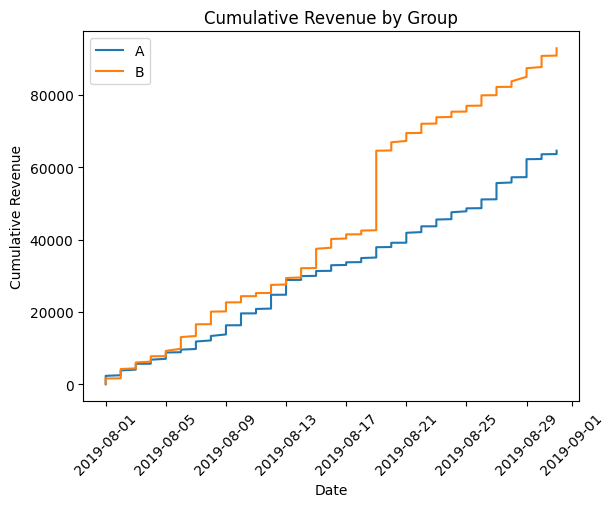

In [15]:
orders=orders.sort_values('date')
orders['cum_revenue']=orders.groupby('group')['revenue'].cumsum()

for g, subset in orders.groupby('group'):
    plt.plot(subset['date'], subset['cum_revenue'], label=g)
plt.legend()
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Cumulative Revenue')
plt.title('Cumulative Revenue by Group')
plt.show()

Group B performs better overall, as it generates higher revenue and shows faster growth. In contrast, Group A demonstrates more stable and consistent growth; the risk is lower, but the growth rate is also relatively slower. Overall, Group A follows a more organic and long-term growth model, while Group B advances with a more aggressive, promotion-driven strategy. If the spike observed in Group B can be replicated, this strategy can be considered highly effective; however, if it is a one-time event, its sustainability remains questionable.

### Cumulative Average Order Size by Group

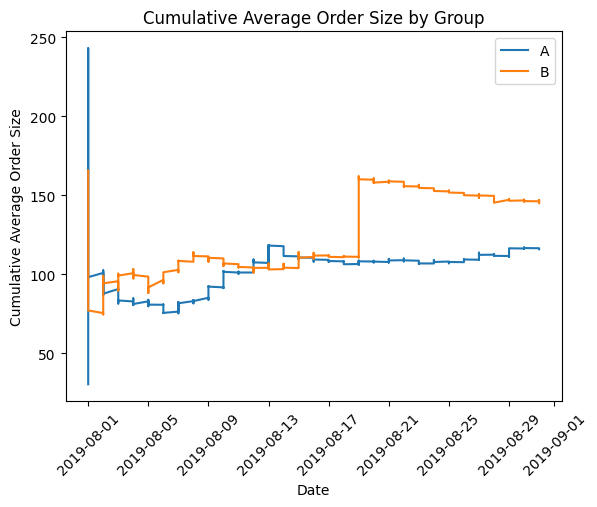

In [16]:
orders = orders.sort_values(['group', 'date'])
orders['cum_orders'] = orders.groupby('group').cumcount() + 1
orders['cum_avg_order'] = orders['cum_revenue'] / orders['cum_orders']

for g, data in orders.groupby('group'):
    plt.plot(data['date'], data['cum_avg_order'], label=g)
plt.legend()
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Cumulative Average Order Size')
plt.title('Cumulative Average Order Size by Group')
plt.show()

The cumulative average order size of group B is higher than that of group A, indicating that users in variant B, on average, spend more. Group A shows more stable and gradual growth, while group B exhibits more variability, which may suggest the presence of high-value transactions (outliers) in B. Overall, the curve for group B remains consistently higher over time, indicating that variant B tends to generate a higher average order value in the long run.

### Relative Difference in Cumulative Average Order Size

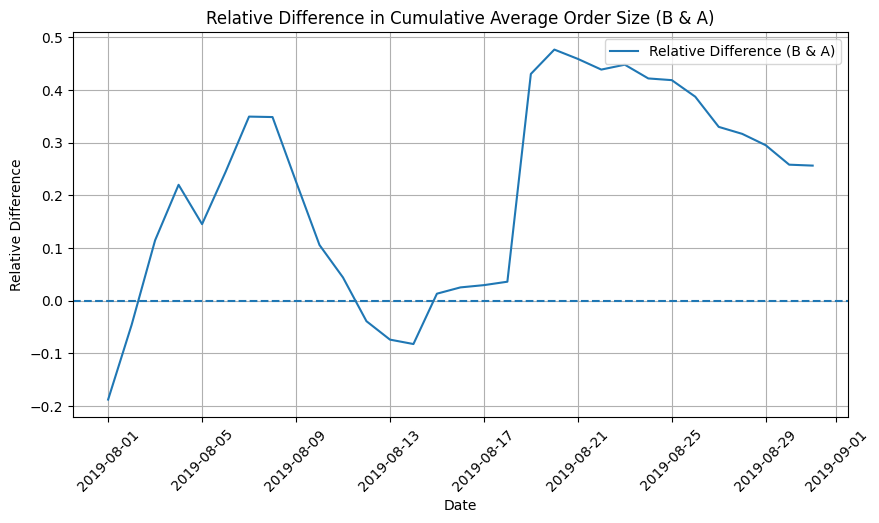

In [17]:
pivot = orders.pivot_table(index='date',columns='group',values='cum_avg_order')
pivot = pivot.sort_index()
pivot['relative_diff'] = (pivot['B'] - pivot['A']) / pivot['A']

plt.figure(figsize=(10, 5))
plt.plot(pivot.index, pivot['relative_diff'], label='Relative Difference (B & A)')
plt.axhline(0, linestyle='--')
plt.legend()
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Relative Difference')
plt.title('Relative Difference in Cumulative Average Order Size (B & A)')
plt.grid(True)
plt.show()

Group B demonstrates a higher average order size overall, which is a strong business signal indicating more revenue per order. However, its performance is not stable and shows high volatility, while there are periods of very strong results, there are also sharp declines at other times. In contrast, Group A performs more consistently and serves as a reliable benchmark for comparison.

### Daily Conversion Rate by Group

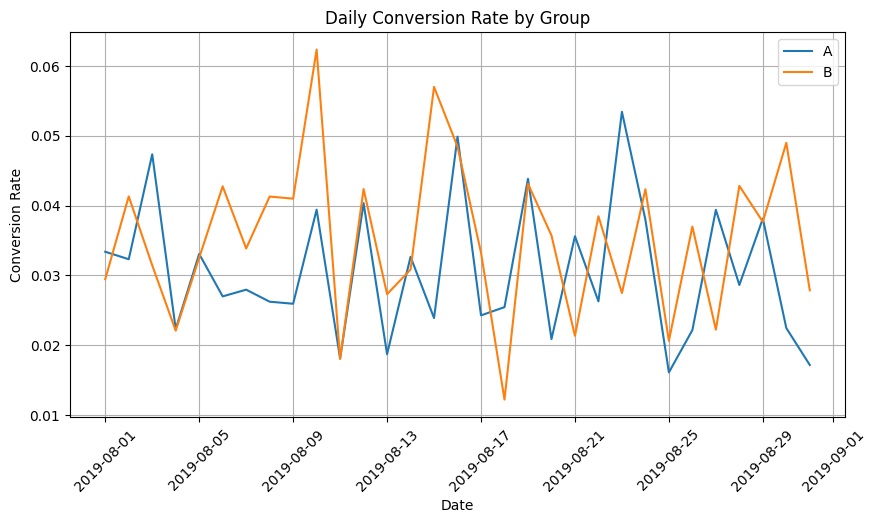

In [18]:
orders_per_day=(orders.groupby(['date', 'group']).agg(orders_count=('transactionId', 'count')).reset_index())
df_merged=pd.merge(orders_per_day, visits, on=['date', 'group'])
df_merged['conversion_rate']=df_merged['orders_count']/df_merged['visits']
pivot=df_merged.pivot(index='date', columns='group', values='conversion_rate')

plt.figure(figsize=(10,5))
for group in pivot.columns:
    plt.plot(pivot.index, pivot[group], label=group)
plt.legend()
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Conversion Rate')
plt.title('Daily Conversion Rate by Group')
plt.grid(True)
plt.show()

Based on the given graph, group B shows a higher conversion rate than group A on most days. Although there are fluctuations over time, the overall trend indicates that group B consistently performs better, while group A appears more stable but remains at a lower level. Therefore, the visual data suggests that group B is more effective in terms of conversion rate.

### Distribution of Orders per User

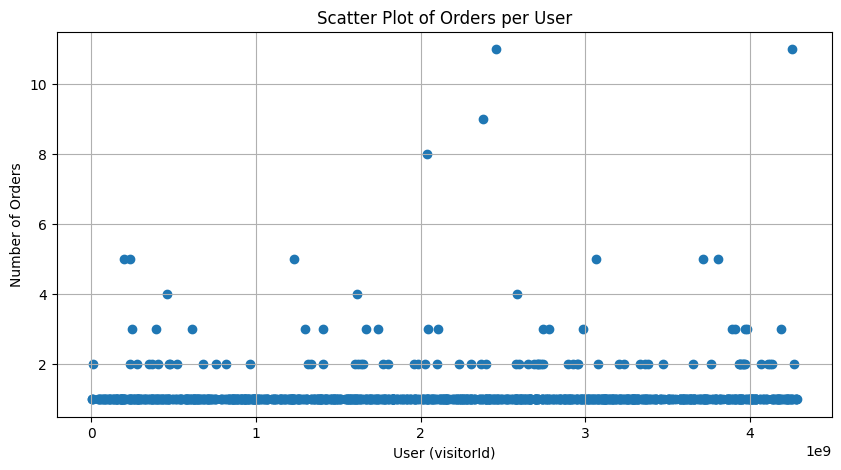

In [19]:
orders_per_user=(orders.groupby('visitorId').agg(orders_count=('transactionId', 'count')).reset_index())

plt.figure(figsize=(10,5))
plt.scatter(orders_per_user['visitorId'], orders_per_user['orders_count'])
plt.xlabel('User (visitorId)')
plt.ylabel('Number of Orders')
plt.title('Scatter Plot of Orders per User')
plt.grid(True)
plt.show()

The scatter plot shows that the majority of users place only one order, indicating low retention on the platform. A smaller number of users place 2–3 orders, representing returning users, but this group is relatively limited, suggesting a weak loyal user base. Additionally, there are a few outliers who place 5 or more orders, which may represent highly active customers or business/reseller-type users. Furthermore, the random distribution of points along the x-axis indicates that there is no correlation between user ID and the number of orders, meaning a user’s ID does not reflect their activity level on the platform.

### Anomaly Users

In [20]:
p95 = orders_per_user['orders_count'].quantile(0.95)
p99 = orders_per_user['orders_count'].quantile(0.99)
print("95th percentile:", p95)
print("99th percentile:", p99)

95th percentile: 2.0
99th percentile: 4.0


95th percentile = 2 → 95% of users make at most 2 orders

99th percentile = 4 → 99% of users make at most 4 orders

This shows that most users are low-frequency buyers, while a small group of users makes many repeated purchases. The distribution is right-skewed with a small number of high-frequency users (outliers) that can significantly affect overall metrics.

### Distribution of Order Prices

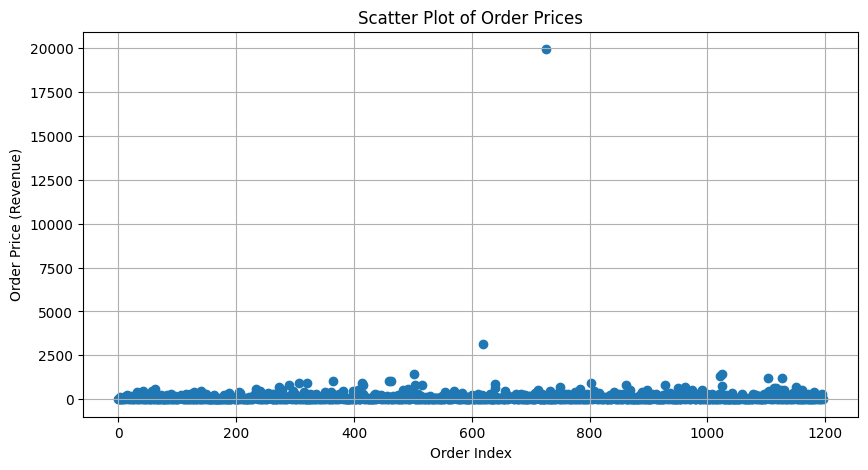

In [21]:
orders_sorted = orders.sort_values('date')
orders_sorted['order_index'] = range(len(orders_sorted))

plt.figure(figsize=(10,5))
plt.scatter(orders_sorted['order_index'], orders_sorted['revenue'])
plt.xlabel('Order Index')
plt.ylabel('Order Price (Revenue)')
plt.title('Scatter Plot of Order Prices')
plt.grid(True)
plt.show()

The scatter plot shows that most orders have low prices (below 1000), indicating the platform mainly handles low-value transactions. A few orders fall in the 1000–3000 range, and there are rare high-value outliers, including one around 20,000. The random distribution across the order index shows no clear trend, and overall the data is right-skewed, meaning revenue mostly comes from many small orders with occasional large ones.

### Conversion Rate Z-test

In [22]:
orders_per_group=orders.groupby('group')['transactionId'].count()
visits_per_group=visits.groupby('group')['visits'].sum()
conversion=orders_per_group/visits_per_group

from statsmodels.stats.proportion import proportions_ztest

successes = orders_per_group.values
trials = visits_per_group.values
z_stat, p_value = proportions_ztest(successes, trials)
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: -2.2700
P-value: 0.0232


Since p-value (0.023) < 0.05, the difference in conversion rates between groups A and B is statistically significant. The observed difference is unlikely due to random chance. There is evidence that one group truly performs better in terms of conversion.

Since significance is detected, the change between A and B has a real impact on user behavior.

### Revenue T-test Between Groups

In [23]:
group_A=orders[orders['group']=='A']['revenue']
group_B=orders[orders['group']=='B']['revenue']

from scipy import stats

t_stat, p_value = stats.ttest_ind(group_A, group_B, equal_var=False)
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: -2.2700
P-value: 0.3745


Since p-value (0.375)>0.05, the difference in average order size between groups A and B is not statistically significant. The observed difference in Average Order Value could be due to random variation. We do not have enough evidence to say that one group has a higher average order size than the other.

Even if group B appeared to have higher cumulative average order size in earlier plots, this may be influenced by random fluctuations or a small number of large orders (outliers).

### Filtered Conversion Z-test

In [24]:
orders_per_user = orders.groupby('visitorId', as_index=False).agg({'transactionId': 'nunique'})
orders_per_user.columns = ['visitorId', 'orders']
anomalous_users = orders_per_user[orders_per_user['orders'] > 4]['visitorId']
filtered_orders = orders[~orders['visitorId'].isin(anomalous_users)].copy()
orders_per_group_filt = filtered_orders.groupby('group')['transactionId'].count()
visits_per_group_filt = visits.groupby('group')['visits'].sum()
# Remove outlier users (users with more than 4 orders) to ensure a more stable and realistic analysis

from statsmodels.stats.proportion import proportions_ztest

successes = [orders_per_group_filt['A'], orders_per_group_filt['B']]
trials = [visits_per_group_filt['A'], visits_per_group_filt['B']]
z_stat, p_value = proportions_ztest(successes, trials)
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: -2.3764
P-value: 0.0175


In both cases p-value < 0.05, therefore, the difference in conversion rates between groups A and B is statistically significant. After filtering out outliers the p-value became even smaller. Since the effect persists after filtering it reflects typical user behavior, not just a small subset of users.

### Revenue T-test Filtered

In [25]:
group_A_filt=filtered_orders[filtered_orders['group']=='A']['revenue']
group_B_filt=filtered_orders[filtered_orders['group']=='B']['revenue']
# Compare average revenue between group A and group B using filtered (outlier-removed) data with an independent t-test

from scipy import stats

t_stat, p_value=stats.ttest_ind(group_A_filt, group_B_filt, equal_var=False)
print(f"t-statistic:: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

t-statistic:: -0.7851
P-value: 0.4327


In both cases p-value > 0.05, therefore, the difference in average order size (AOV) between groups A and B is not statistically significant. After filtering out outliers, the p-value increased. This confirms that outliers were not creating a real effect. The experiment affects conversion rate, but not spending behavior.

# Conclusion

One variant clearly improves conversion without harming order value, and the effect is statistically significant and consistent.

Stop the test and choose the leader.

The group with higher conversion (B) should be considered the leader and implemented as the winning variant. The winning group increases the number of purchases (conversion). It does not negatively affect how much users spend per order. Therefore, the overall impact on business metrics is positive.